In [109]:
import torch
from torch import nn
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l
import matplotlib.pyplot as plt

In [ ]:
batch_size = 256
train_iter,test_iter = d2l.load_data_fashion_mnist(batch_size)

In [ ]:
## initialization
num_inputs,num_outputs,num_hiddens = 784,10,256
W1 = nn.Parameter(
    torch.randn(num_inputs,num_hiddens,requires_grad=True)*0.01
)
b1 = nn.Parameter(
    torch.zeros(num_hiddens,requires_grad=True)
)
W2 = nn.Parameter(
    torch.randn(num_hiddens,num_outputs,requires_grad=True)*0.01
)
b2 = nn.Parameter(
    torch.zeros(num_outputs,requires_grad=True)
)
params = [W1,b1,W2,b2]


In [ ]:
## relu
def relu(X):
   a = torch.zeros_like(X)
   return torch.max(X,a)

In [ ]:
## 计算 accuracy
def accuracy(y_hat,y):
    if len(y_hat.shape) >1 and y_hat.shape[1] >1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y ## 将预测结果和label一一比较
    return float(cmp.type(y.dtype).sum())   

In [ ]:
## net
def net(X):
    X = X.reshape(-1,num_inputs)
    H = relu(X@W1 + b1)
    return (H@W2 + b2)

In [ ]:
loss = nn.CrossEntropyLoss(reduction='none')

In [ ]:
## train
num_epochs,lr = 10,0.1
updater = torch.optim.SGD(params, lr=lr)


In [ ]:
class Accumulator: #@save
    def __init__(self,n):
        self.data = [0.0]*n ## 维护data列表，data[0]为正确预测数，data[1]为总数
    
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]

In [ ]:
def evaluate_accuracy(data_iter,net): #@save
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:  
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1] 



In [ ]:
# trainning for one epoch
def train_epoch_softmax(net,train_iter,updater,loss):
    if isinstance(net,torch.nn.Module):
        net.train() ## tranning mode
    metric = Accumulator(3) ## 维护训练损失总和、训练准确度总和、样本数
    for X,y in train_iter:
        ## 计算梯度
        y_hat = net(X)
        l = loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer): ##如果updater属于torch内置优化器
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0]) ## 自定义优化器时，确定当前batch里有多少样本，求平均梯度
        metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())  
    return metric[0]/metric[2], metric[1]/metric[2]
    


In [ ]:
def train_softmax(net, train_iter, test_iter, loss, updater, num_epochs):
    for epoch in range(num_epochs):

        train_loss, train_accuracy = train_epoch_softmax(
            net, train_iter, updater, loss
        )

        test_accuracy = evaluate_accuracy(
            test_iter,net
        )

        print(
            f'epoch {epoch + 1}, '
            f'train loss {train_loss:.3f}, '
            f'train acc {train_accuracy:.3f}, '
            f'test acc {test_accuracy:.3f}'
        )


In [ ]:
train_softmax(net, train_iter, test_iter, loss, updater, num_epochs)

In [ ]:
def get_fashion_minst_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [107]:
def show_figure(imgs,num_rows,num_columns,titles=None,scale=1.5):
    ## 计算图片大小
    figsize = [num_columns*scale,num_rows*scale]
    _, axes = plt.subplots(
        num_rows,
        num_columns,
        figsize = figsize

    )
    axes = axes.flatten() ## 将图片展开为1维，便于遍历
    for i, (ax,img) in enumerate(zip(axes,imgs)): ## zip()将画布和图片zip合在一起，enumerate编号
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])

    return axes


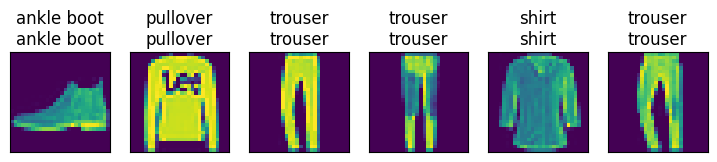

In [110]:
def predict_softmax(net,test_iter,n=6):
    for X,y in test_iter: ## 就用第一个epoch拿出来看看
        break
    trues = get_fashion_minst_labels(y)
    predticts = get_fashion_minst_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, predticts)]
    show_figure(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n]
    )

predict_softmax(net,test_iter)